# 3. Bandes électroniques 



In [18]:
import numpy as np
import matplotlib.pyplot as plt

from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

import json

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)

    bandstructure = mpr.get_bandstructure_by_material_id(MP_ID)

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<00:00, 4328.49it/s]


## 3.2 déterminer les trois premiers pics du diffractogramme correspondant (en indiquant les indices hkl associés) pour un rayonnement X incident Cu Kα de longueur d'onde λ=1.54060 Å.

## 3.3 Structure de bandes électroniques 


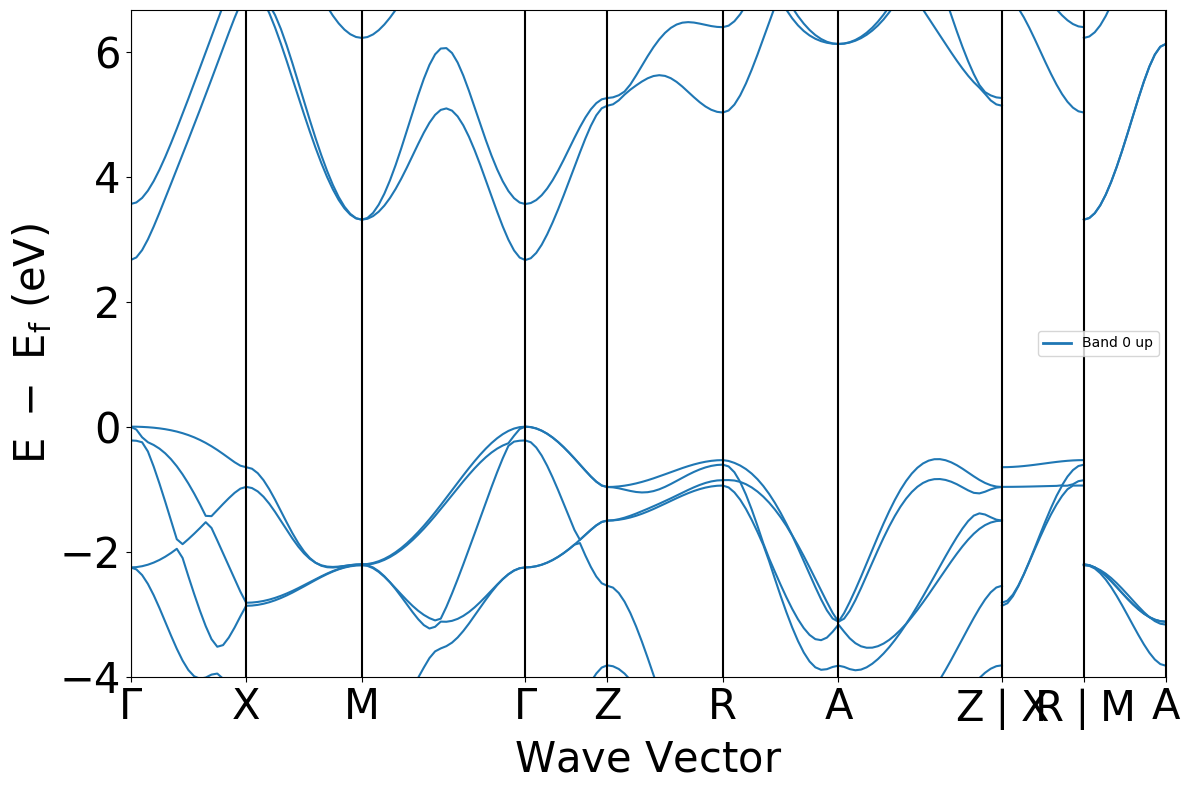

In [19]:
plotter = BSPlotter(bandstructure)
fig = plotter.get_plot()  # renvoie une figure matplotlib (souvent)

plt.savefig(f"{MP_ID}_el_bandstructure.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.4 Bande interdite



La largeur de la bande interdite est de: 2.6642 eV
La bande interdite de ce matériau est direct
La transistion est en: \Gamma-\Gamma


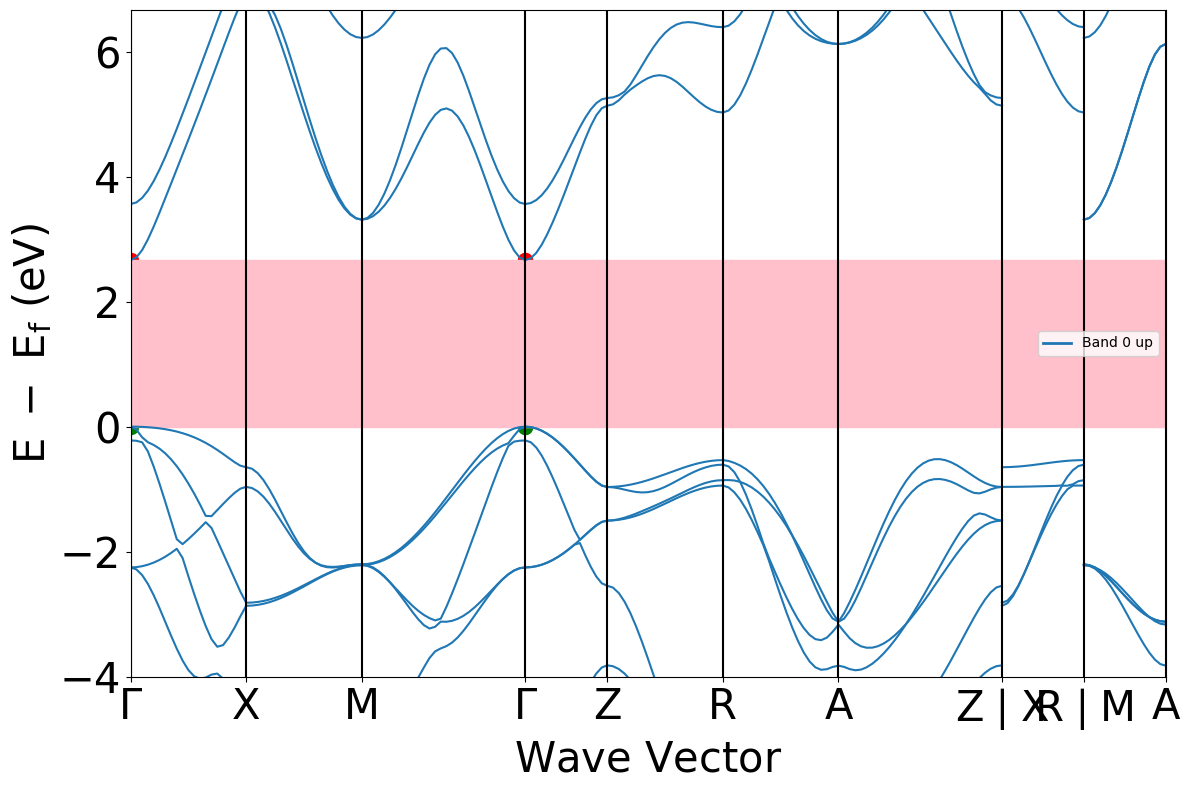

In [20]:
band_gap = bandstructure.get_band_gap()
plot_bs = BSPlotter(bandstructure) 

data = plot_bs.bs_plot_data()
energy = band_gap.get('energy')
distance = data.get('ticks').get('distance')

plot_bs.get_plot(vbm_cbm_marker=True)
plt.fill_between(np.linspace(distance[0], distance[-1], 2), 0, energy, color = "pink")



print("La largeur de la bande interdite est de:", band_gap["energy"],"eV")
if band_gap["direct"] is True:
    print("La bande interdite de ce matériau est direct")
if band_gap["direct"] is False:
    print("La bande interdite de ce matériau est indirect")
print("La transistion est en:", band_gap["transition"])


## 3.5 Dispersion 

### 1) Première bande de conduction 

In [21]:
cbm = bandstructure.get_cbm()
print(cbm["band_index"])

defaultdict(<class 'list'>, {<Spin.up: 1>: [13]})


### 2) Dernière bande de valence 

In [22]:
vbm = bandstructure.get_vbm()
print(vbm["band_index"])

defaultdict(<class 'list'>, {<Spin.up: 1>: [11, 12]})


### 3) Calcul des directions 

In [23]:
distances = data['distances']
energy = data['energy']

Valence = [] 
Conduction = []

for i in range(len(distances)):
    dx = distances[i][0]-distances[i][-1]
    
    dy_Valence = energy['1'][i][9][0]-energy['1'][i][9][-1] 
    dy_Conduction = energy['1'][i][10][0]-energy['1'][i][10][-1]
    
    slope_Valence = abs(dy_Valence/dx)
    slope_Conduction = abs(dy_Conduction/dx)
    
    Conduction.append(slope_Conduction)
    Valence.append(slope_Valence)
    
    
Valence_max = Valence.index(max(Valence))
Valence_min = Valence.index(min(Valence))
Cond_max = Conduction.index(max(Conduction))
Cond_min = Conduction.index(min(Conduction))

print("Sur la dernière bande de valence, la plus grande dispersion se trouve sur le 'chemin' d'indice", Valence_max,
      "(entre U et W) et la plus \npetite sur celui d'indice", Valence_min,"(entre Γ et L).\n")
print("Pour la première bande de conduction, la plus grande dispersion se trouve sur le 'chemin' d'indice",Cond_max,
      "(entre Γ et L) et la \nplus petite sur celui d'indice", Cond_min,"(entre W et K).\n")

Sur la dernière bande de valence, la plus grande dispersion se trouve sur le 'chemin' d'indice 5 (entre U et W) et la plus 
petite sur celui d'indice 2 (entre Γ et L).

Pour la première bande de conduction, la plus grande dispersion se trouve sur le 'chemin' d'indice 7 (entre Γ et L) et la 
plus petite sur celui d'indice 1 (entre W et K).



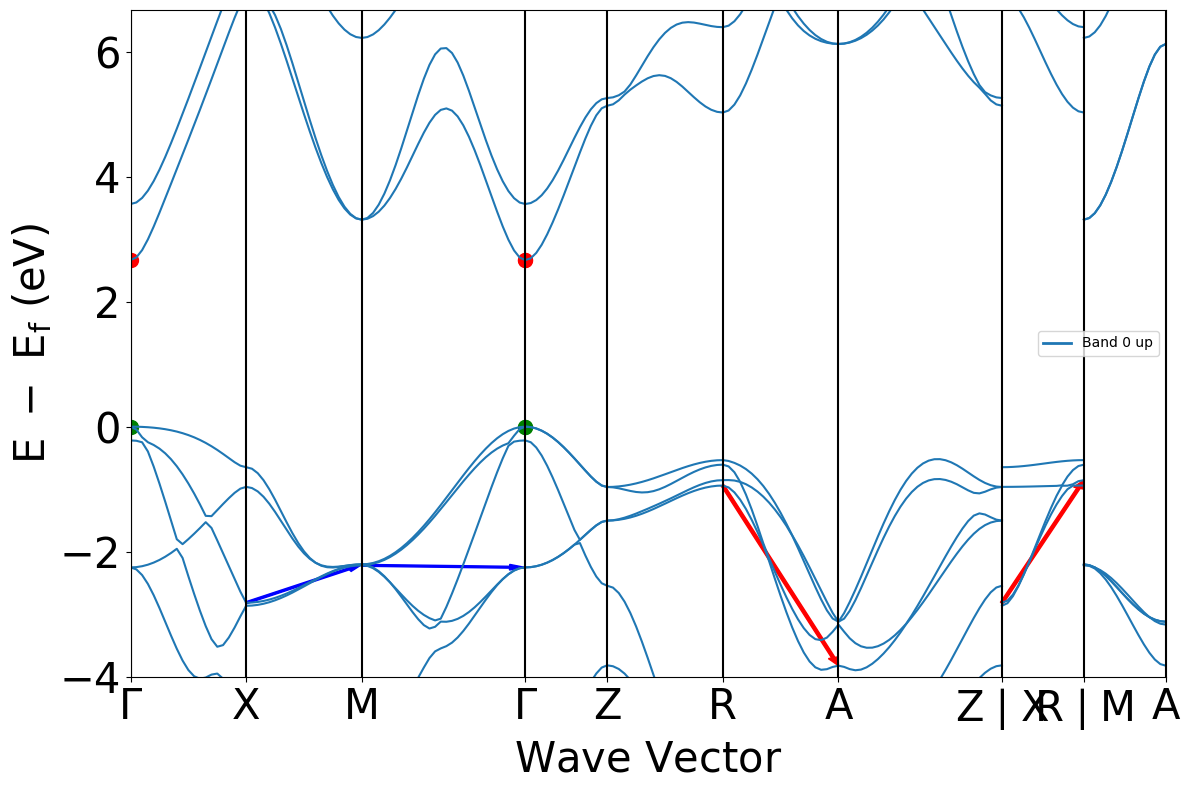

In [24]:
plot_bs.get_plot(vbm_cbm_marker=True)

# Bande de valence avec la plus petite dispertion
plt.arrow(distances[Valence_min][0], energy['1'][Valence_min][9][0], 
          distances[Valence_min][-1]-distances[Valence_min][0],
          energy['1'][Valence_min][9][-1]-energy['1'][Valence_min][9][0],
          width = 0.03,length_includes_head=True,color='blue') 

# Bande de valence avec la plus grande dispertion
plt.arrow(distances[Valence_max][0],energy['1'][Valence_max][9][0], 
          distances[Valence_max][-1]-distances[Valence_max][0],
          energy['1'][Valence_max][9][-1]-energy['1'][Valence_max][9][0],
          width = 0.03,length_includes_head=True,color='red') 

# Bande de conduction avec la plus petite dispertion
plt.arrow(distances[Cond_min][0],energy['1'][Cond_min][10][0], 
          distances[Cond_min][-1]-distances[Cond_min][0],
          energy['1'][Cond_min][10][-1]-energy['1'][Cond_min][10][0],
          width = 0.03,length_includes_head=True,color='blue')

# Bande de conduction avec la plus grande dispertion
plt.arrow(distances[Cond_max][0], energy['1'][Cond_max][10][0],
          distances[Cond_max][-1]-distances[Cond_max][0],
          energy['1'][Cond_max][10][-1]-energy['1'][Cond_max][10][0],
          width = 0.03,length_includes_head=True,color='red') 

plt.show()

## 3.6 Masse effective